# Multimodel Incident Resolution on Arango

An incident-resolution agent on the Arango Contextual Data Platform. A fresh alert comes in; one AQL query returns the most similar past incidents (vector search), the affected-service subgraph (graph traversal), and the on-call team (key-value lookup) — document, vector, graph, and key-value in one store, one query, one round trip. A GraphRAG knowledge graph over the runbooks then grounds a cited, natural-language fix.

**Prereqs:** `pip install -r requirements.txt`, and a `.env` with your Arango host/credentials + `OPENAI_API_KEY` + `GRAPHRAG_PROJECT`/`GRAPHRAG_DB` (see `.env.example`).

In [1]:
import json
from openai import OpenAI
from datasets import load_dataset

# Helpers live in ingest.py so the notebook and the scripts share one source of truth.
from ingest import connect, embed, EMBED_MODEL, EMBED_DIM, DATASET

db = connect()
oai = OpenAI()
topo = json.load(open("data/topology.json"))
print("connected:", db.name)

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


connected: incident_demo


## 1. Schema — one store, four shapes

A document collection for incidents, a `services` + `service_depends_on` named graph for the topology, and a `teams` collection for on-call ownership. (Re-run safe: we drop and recreate.)

In [2]:
if db.has_graph("service_topology"):
    db.delete_graph("service_topology")
for c in ["incidents", "services", "teams", "service_depends_on"]:
    if db.has_collection(c):
        db.delete_collection(c)

incidents = db.create_collection("incidents")
services = db.create_collection("services")
teams = db.create_collection("teams")
graph = db.create_graph("service_topology")
graph.create_edge_definition(
    edge_collection="service_depends_on",
    from_vertex_collections=["services"],
    to_vertex_collections=["services"],
)
print("schema ready")

schema ready


## 2. Service topology + on-call teams

Hand-authored in `topology.json` — the dataset ships no CMDB, so a small curated graph keeps the traversal legible. In production these edges come from your real service map.

In [3]:
services.insert_many([{"_key": k, **v} for k, v in topo["services"].items()])
teams.insert_many([{"_key": k, **v} for k, v in topo["teams"].items()])
db.collection("service_depends_on").insert_many(
    [{"_from": f"services/{a}", "_to": f"services/{b}"} for a, b in topo["depends_on"]]
)
print(f"{services.count()} services, {teams.count()} teams, {db.collection('service_depends_on').count()} edges")

12 services, 5 teams, 13 edges


## 3. Tickets — load, embed, index

We pull `6StringNinja/synthetic-servicenow-incidents` (500 rows, MIT), embed `short_description + description`, keep the `resolution` text, and attach each incident to a service via its category. The vector index is created **after** the load so it trains on the full set.

In [4]:
ds = load_dataset(DATASET, split="train")
cat2svc = topo["category_to_service"]
vectors = embed(oai, [f'{r["short_description"]} {r["description"]}' for r in ds])

incidents.insert_many([
    {
        "_key": r["number"], "short_description": r["short_description"],
        "description": r["description"], "resolution": r["resolution"],
        "category": r["category"], "assignment_group": r["assignment_group"],
        "service": cat2svc.get(r["category"], "onboarding-api"), "embedding": v,
    }
    for r, v in zip(ds, vectors)
])

incidents.add_index({
    "name": "incidents_vec", "type": "vector", "fields": ["embedding"],
    "params": {"metric": "cosine", "dimension": EMBED_DIM, "nLists": 10},
})
print(f"{incidents.count()} incidents embedded + indexed")

500 incidents embedded + indexed


## 4. Resolve an alert — the multimodel query

One AQL query does three moves: `APPROX_NEAR_COSINE` (vector) finds similar incidents, `OUTBOUND ... GRAPH` (graph) expands the affected-service subgraph, and `DOCUMENT` (key-value) returns the on-call team. The full query lives in `resolver.py`.

In [5]:
from resolver import MARQUEE, resolve
print(MARQUEE)


LET similar = (
  FOR i IN incidents
    LET sim = APPROX_NEAR_COSINE(i.embedding, @vec)
    SORT sim DESC
    LIMIT 3
    RETURN {
      number: i._key,
      short_description: i.short_description,
      resolution: i.resolution,
      service: i.service,
      similarity: sim
    }
)
LET root = @service != null ? @service : FIRST(similar).service
LET affected = (
  FOR v, e, p IN 0..3 OUTBOUND CONCAT("services/", root) GRAPH "service_topology"
    COLLECT service = v._key, name = v.name AGGREGATE depth = MIN(LENGTH(p.edges))
    SORT depth
    RETURN {service, name, depth}
)
LET team = DOCUMENT("teams", DOCUMENT("services", root).team)
RETURN {
  root_service: root,
  similar_incidents: similar,
  affected_services: affected,
  on_call: {team: team.name, contact: team.oncall}
}



In [6]:
alert = json.load(open("data/alert.sample.json"))
print(json.dumps(resolve(alert), indent=2))

{
  "root_service": "onboarding-api",
  "similar_incidents": [
    {
      "number": "INC00311",
      "short_description": "Merchant unable to e-sign agreement",
      "resolution": "The network team identified a routing issue causing the intermittent connections and resolved it by optimizing the network configuration to ensure stable and uninterrupted service.",
      "service": "auth-service",
      "similarity": 0.8412302136421204
    },
    {
      "number": "INC00469",
      "short_description": "Access Rights Restriction",
      "resolution": "Development team identified a bug in the service configuration module that was blocking the setup. A code fix was deployed, allowing Sales Agent to configure services for the additional location.",
      "service": "onboarding-api",
      "similarity": 0.8315454721450806
    },
    {
      "number": "INC00354",
      "short_description": "Equipment selection dropdown missing options",
      "resolution": "User permissions for the Sales Age

The payload is the structured answer: ranked similar incidents (with how each was resolved), the affected-service subgraph by depth, and who to page. Next we turn that into a cited, runbook-grounded fix — the `answer()` seam in `resolver.py`, backed by a GraphRAG knowledge graph.

## 5. The runbook knowledge graph (GraphRAG)

The structured payload says *what* broke and *who* owns it. To say *how to fix it* in grounded prose, we import the runbooks in `runbooks/` into a GraphRAG knowledge graph — entities, relations, communities, and chunk embeddings — queried through the Retriever. The build runs once and is skipped if the graph already exists (`graphrag_ingest.main(reset=True)` rebuilds). Services are deployed once via the platform UI; postfixes are discovered at runtime in `graphrag.py`, never hardcoded.

In [7]:
import graphrag_ingest
graphrag_ingest.main()  # skip-if-built; pass --reset on the CLI to rebuild

from graphrag import GRAPHRAG_PROJECT, kg_db
kdb = kg_db()
for c in ["Documents", "Entities", "Relations", "Communities"]:
    print(f"{c:12}", kdb.collection(f"{GRAPHRAG_PROJECT}_{c}").count())

KG already built (skip; pass --reset to rebuild).
KG verification:


  test-incident-demo_Documents: 11
  test-incident-demo_Chunks: 11


  test-incident-demo_Entities: 80
  test-incident-demo_Communities: 1


  test-incident-demo_Relations: 120
  graph test-incident-demo_kg: True | PASS: True


Documents    11
Entities     80
Relations    120


Communities  1


## 6. The cited, grounded answer

`answer()` queries the Retriever's Local Search and grounds the next step in the **exact** root-service runbook the AQL query pinpointed (primary citation), then appends GraphRAG's related blast-radius runbooks. `corroborated()` independently checks that a cited runbook references the root or an affected service — the precise AQL surface and the semantic GraphRAG surface converging on the same incident.

In [8]:
from resolver import answer, corroborated

payload = resolve(alert)
cited = answer(payload, alert["text"])
print(cited["text"], "\n")
for k, c in cited["citations"].items():
    tag = " (primary)" if c.get("primary") else ""
    label = c.get("file_name") or c.get("citable_url", "?")
    print(f"[{k}]{tag} {label}")
print("\ncorroboration:", corroborated(payload, cited))

## Overview

The onboarding-api for merchants is encountering incidents during the e-signing process, specifically when merchants attempt to sign the Merchant Agreement. This issue presents as a permission error during the onboarding process, leading to a failure at the document step.

## Recommended Resolution

The runbook for the onboarding-api outlines several possible resolutions based on the root cause of the incident:

1. **Document-Service Degraded**: If the `document-service` is experiencing degradation, it is necessary to page the Onboarding On-Call team, scale the `document-service`, and adhere to the steps outlined in the document-service runbook [[1](https://runbooks.internal/notification-service-delivery-failure)].

2. **Stale Permission Cache**: If the problem stems from a stale permission cache, it advises invalidating the merchant's permission cache entry and retrying the e-signing step. The cache has a TTL (Time To Live) of 15 minutes, but manual invalidation can resol

## 7. Results across the alert set

The whole alert estate, end to end. `evaluate()` runs every alert in `data/alerts.json` through `resolve()` + `answer()` and times both halves: the **multimodel query** (one AQL round trip — vector + graph + key-value) and the **cited GraphRAG answer**. For each alert the table below shows what the system actually delivered — the most similar past incident it found, the blast radius, the on-call owner, the runbook it grounded on — and whether the two surfaces corroborate.

The headline: every alert grounds on the correct service runbook and corroborates, and the multimodel query itself returns in a few milliseconds.

In [9]:
import pandas as pd
from resolver import evaluate

alerts = json.load(open("data/alerts.json"))
results = evaluate(alerts)                 # one row per alert, both timings captured
results_table = pd.DataFrame(results)

total = len(results_table)
grounded = int(results_table["grounded"].sum())
corroborated_count = int(results_table["corroborated"].sum())
median_query_ms = results_table["query_ms"].median()

print(f"{grounded}/{total} grounded on the correct runbook    "
      f"{corroborated_count}/{total} corroborated    "
      f"median multimodel query {median_query_ms:.0f} ms (one round trip)")

# Render the per-alert table (✓/✗ for the two boolean checks).
shown = results_table.assign(
    grounded=results_table["grounded"].map({True: "✓", False: "✗"}),
    corroborated=results_table["corroborated"].map({True: "✓", False: "✗"}),
)
shown[["alert", "service", "severity", "top_similar_incident", "top_similarity",
       "blast_radius", "on_call", "primary_runbook", "grounded", "corroborated",
       "citations", "query_ms", "answer_s"]]

8/8 grounded on the correct runbook    8/8 corroborated    median multimodel query 161 ms (one round trip)


,alert,service,severity,top_similar_incident,top_similarity,blast_radius,on_call,primary_runbook,grounded,corroborated,citations,query_ms,answer_s
0,ALR-001,onboarding-api,P1,INC00311,0.841,8,Onboarding On-Call,onboarding-api-esign-failure.md,✓,✓,2,195.2,5.9
1,ALR-002,payment-gateway,P1,INC00477,0.610,2,Payments On-Call,payment-gateway-declines.md,✓,✓,2,503.8,8.4
2,ALR-003,auth-service,P2,INC00233,0.563,2,Identity On-Call,auth-service-login-latency.md,✓,✓,2,155.6,18.1
3,ALR-004,network-gateway,P1,INC00449,0.448,1,Platform On-Call,network-gateway-egress-saturation.md,✓,✓,2,148.3,7.4
4,ALR-005,user-db,P1,INC00233,0.497,1,Identity On-Call,user-db-replica-lag.md,✓,✓,2,147.4,6.2
5,ALR-006,document-service,P2,INC00421,0.510,2,Onboarding On-Call,document-service-degraded.md,✓,✓,3,233.8,5.8
6,ALR-007,merchant-service,P3,INC00475,0.616,5,Onboarding On-Call,merchant-service-data-mismatch.md,✓,✓,2,146.1,5.4
7,ALR-008,api-gateway,P1,INC00056,0.473,10,Frontend On-Call,api-gateway-5xx.md,✓,✓,2,166.5,5.9


wrote assets/results.png (8/8 grounded, 8/8 corroborated)


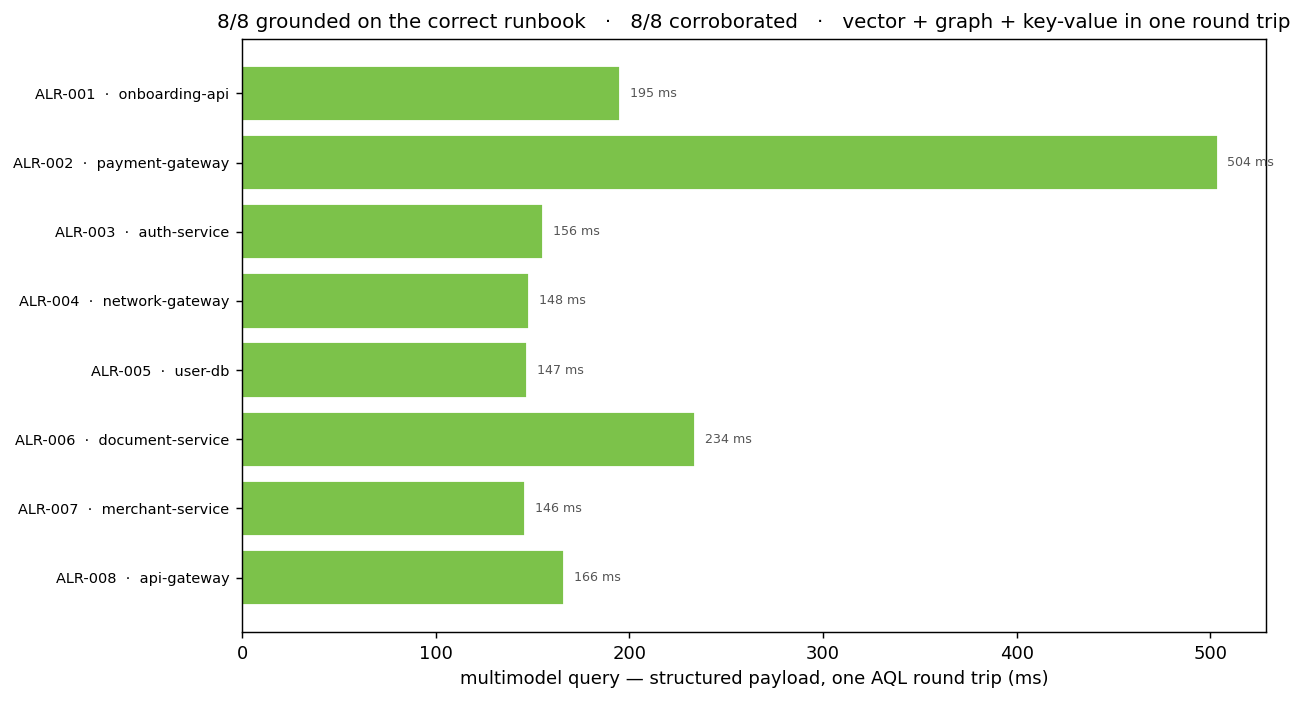


Alert ALR-001 on onboarding-api (P1) -- in full:
  most similar past incident : INC00311 (cosine 0.841)
  blast radius               : 8 services
  on-call                    : Onboarding On-Call
  grounded on                : onboarding-api-esign-failure.md  (corroborated: True)
  next step                  : Resolution and First On-Call Steps for Onboarding-API Incident


In [10]:
# The results figure (regenerated from these rows) + one alert in full -- the value delivered.
import viz
from IPython.display import Image, display

viz.fig_results_from_rows(results)
display(Image("assets/results.png"))

example = results[0]
print(f"\nAlert {example['alert']} on {example['service']} ({example['severity']}) -- in full:")
print(f"  most similar past incident : {example['top_similar_incident']} (cosine {example['top_similarity']})")
print(f"  blast radius               : {example['blast_radius']} services")
print(f"  on-call                    : {example['on_call']}")
print(f"  grounded on                : {example['primary_runbook']}  (corroborated: {example['corroborated']})")
print(f"  next step                  : {example['next_step']}")

### Figures

The blast radius of the headline alert and the runbook knowledge graph, rendered straight from the live deployment (`python viz.py` → `assets/`).

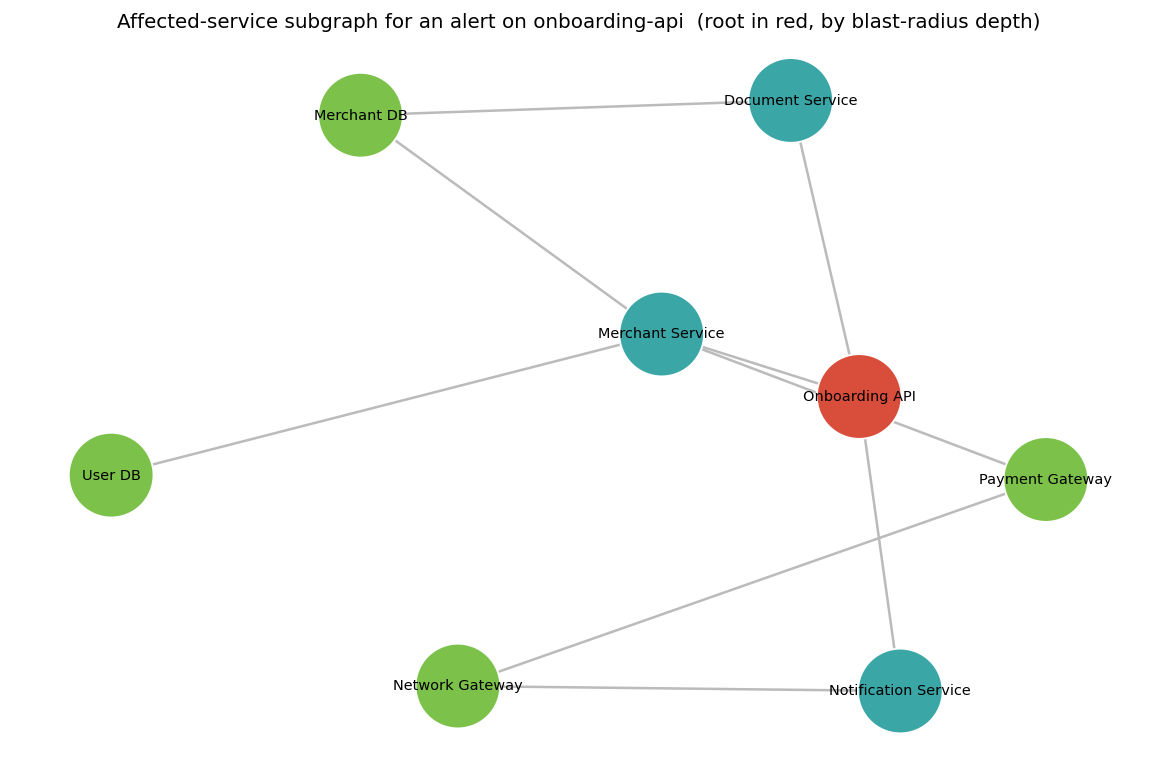

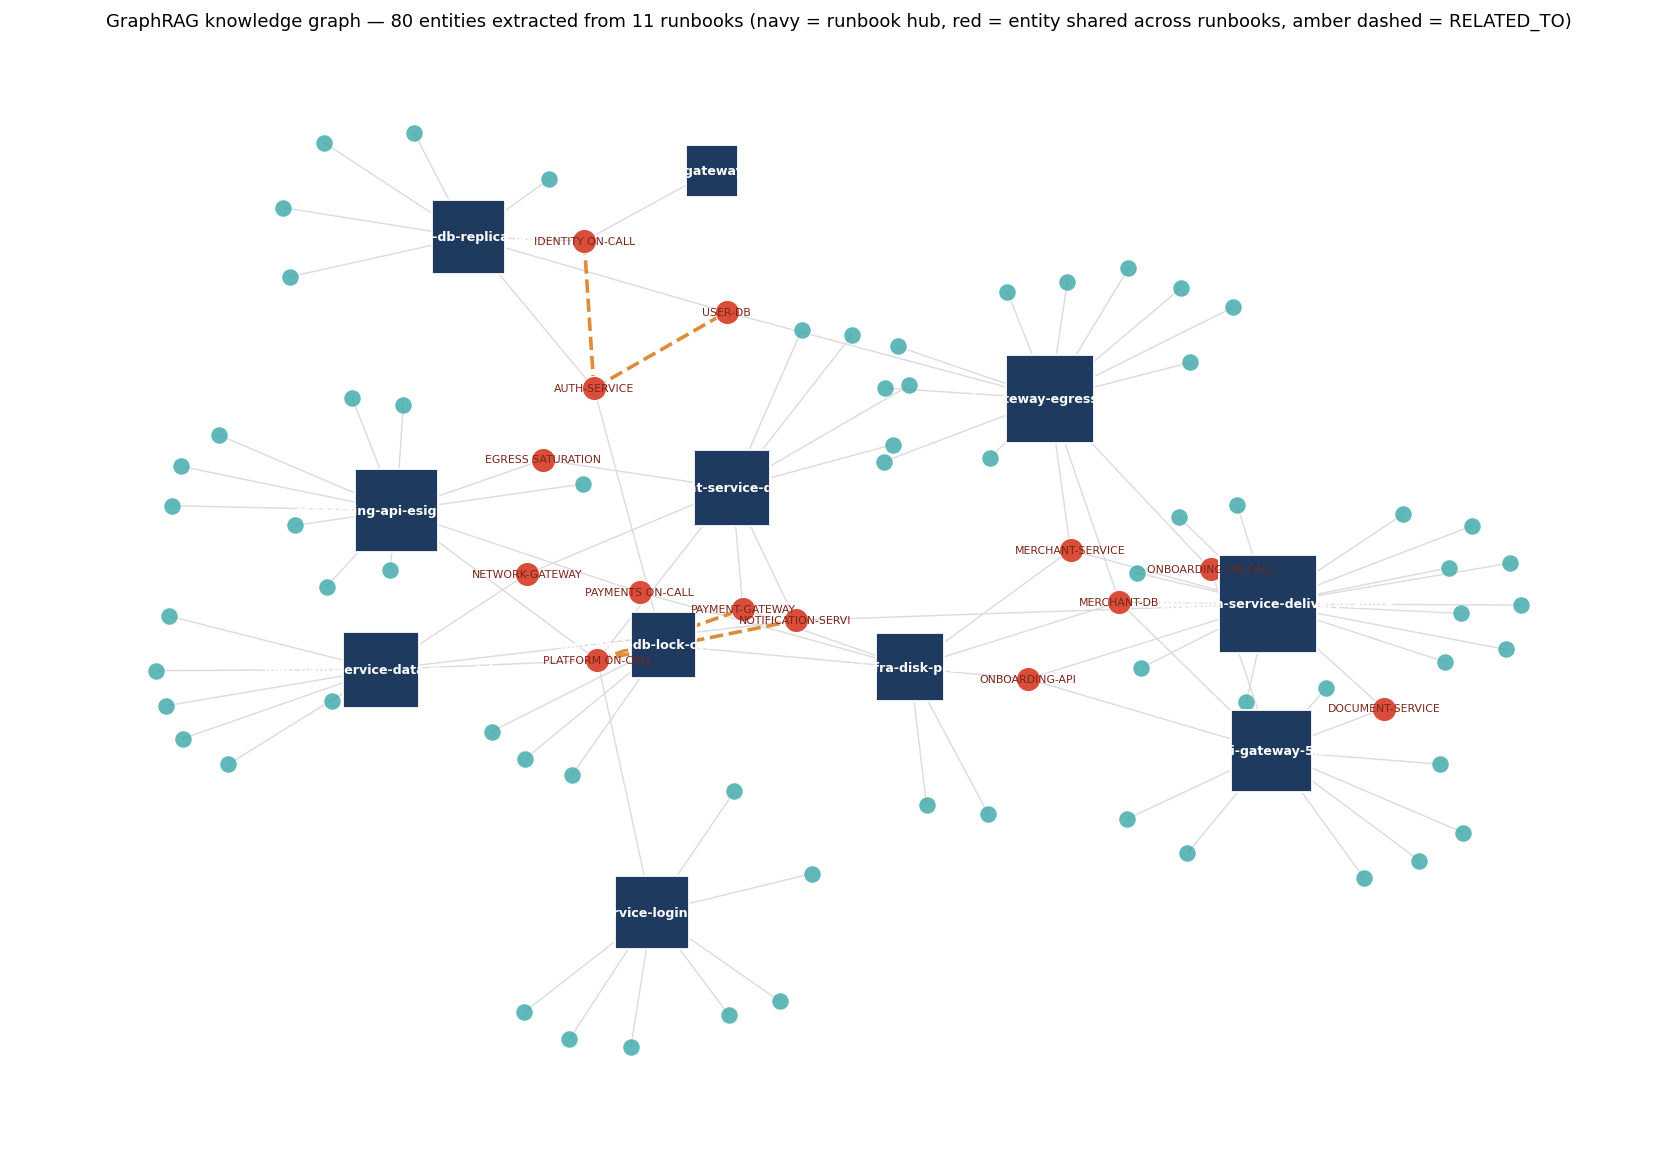

In [11]:
from IPython.display import Image, display
display(Image("assets/affected-subgraph.png"))
display(Image("assets/knowledge-graph.png"))

## What this shows

One Arango Contextual Data Platform deployment resolves an operational alert end to end: vector + graph + key-value in a single AQL round trip for the structured facts (similar incidents, blast radius, on-call), and a GraphRAG knowledge graph for the grounded, cited fix — two independent surfaces that corroborate. No separate vector store, graph database, or retrieval service to stitch together. Scale knobs (ticket slice, runbook count) and extension points (LangChain / LangGraph, Arango's **Ada** assistant) are documented in the README.